# Testing with JAX framework
Better than pytorch (?)

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

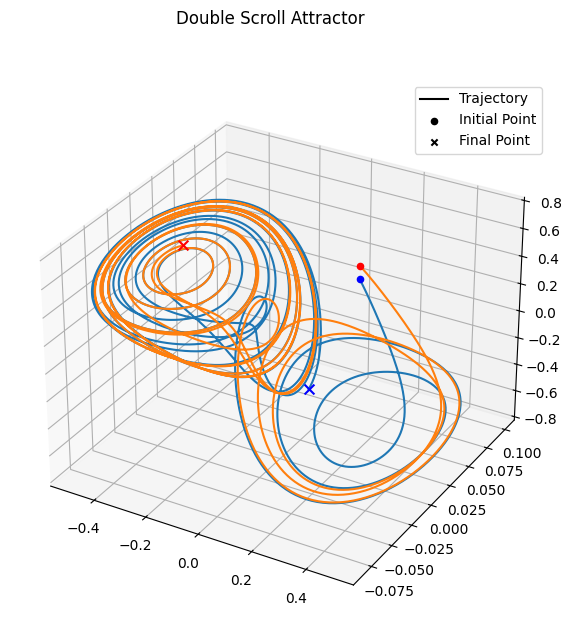

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 35

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
y0_alt = jnp.array((0.0001, 0.1, 0.1))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)
sol_alt = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='3d'), )

ax.plot(sol.ys[:, 0],sol.ys[:, 1],sol.ys[:, 2], color='C0', alpha=1)
ax.scatter(sol.ys[0:1, 0],sol.ys[0:1, 1],sol.ys[0:1, 2], color='blue', marker='o')
ax.scatter(sol_alt.ys[0:1, 0],sol_alt.ys[0:1, 1],sol_alt.ys[0:1, 2], color='red', marker='o')


ax.scatter(sol.ys[-1:, 0],sol.ys[-1:, 1],sol.ys[-1:, 2], color='blue', marker='x', s=50)
ax.scatter(sol_alt.ys[-1:, 0],sol_alt.ys[-1:, 1],sol_alt.ys[-1:, 2], color='red', marker='x', s=50)

ax.plot(sol_alt.ys[:, 0],sol_alt.ys[:, 1],sol_alt.ys[:, 2], color='C1', alpha=1)

ax.plot([], [], label="Trajectory", color='k')
ax.scatter([], [], marker='o', label="Initial Point", color='k')
ax.scatter([], [], marker='x', label="Final Point", color='k')

ax.legend()

plt.suptitle("Double Scroll Attractor")

plt.show()

In [3]:
T_MAX = 10
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.1))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol_train.ys[::1]
    t_train = sol_train.ts[::1]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.15))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::1]
    t_val = sol_val.ts[::1]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [4]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


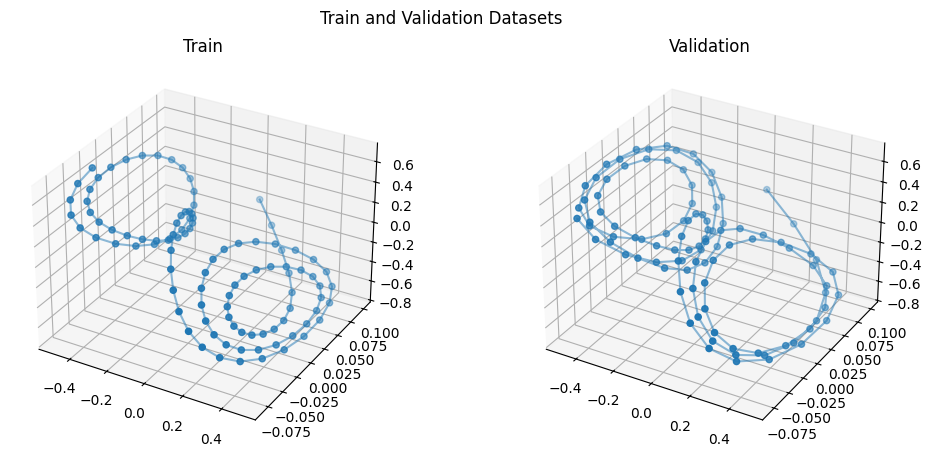

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [6]:
t_train.shape

(100,)

In [7]:
t_val.shape

(100,)

In [8]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [9]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [10]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=3,
            activation=jax.nn.leaky_relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)


In [149]:
class NDEBaseline(eqx.Module):
    net : eqx.nn.MLP

    def __init__(self, key):
        self.net = eqx.nn.MLP(
            in_size=3,
            out_size=3,
            width_size=128,
            depth=5,
            activation=jax.nn.relu, 
            key=key 
        )

    def __call__(self, t, y, args):
        return self.net(y)

In [150]:
class ChuaUdeX(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 

    def __init__(self, alpha, beta, gamma, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=128,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    

    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)


In [13]:
def solve_ude(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Kvaerno3()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [14]:
def solve_ude_light(model, y0, ts):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-6, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper
    )
    return sol.ys



In [ ]:
key = jr.PRNGKey(0)
nde = NDEBaseline(key)

# Train baseline NDE
lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(nde, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

baseline_train_losses = []
baseline_val_losses = []

for i in range(0, n_epochs):
    nde, opt_state, loss = train_step(nde, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(nde, x_val[0], x_val, t_val)[0]
 
    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    baseline_train_losses.append(loss)
    baseline_val_losses.append(val_loss)

In [22]:
key = jr.PRNGKey(0)
ude = ChuaUdeX(ALPHA, BETA, GAMMA, key)

# Train Normal UDE
lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude, eqx.is_inexact_array))

@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts):
    # calculate loss
    pred = solve_ude_light(model, x0, ts)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

train_losses = []
val_losses = []

for i in range(0, n_epochs):
    ude, opt_state, loss = train_step(ude, opt_state, x_train[0], x_train, t_train, optimizer)

    val_loss = loss_fn(ude, x_val[0], x_val, t_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses.append(loss)
    val_losses.append(val_loss)

0	8.0243e-02	8.2349e+01
1	2.7679e+01	4.2193e-02
2	7.9763e-02	1.3737e+03
3	8.1589e+01	1.6833e-01
4	9.7852e-02	2.8404e+00
5	1.0024e+00	2.0597e+00
6	1.1038e+00	7.4992e-01
7	7.0350e-01	1.7762e-01
8	2.5068e-01	5.4166e-02
9	9.0069e-02	9.0676e+06
10	3.0395e+03	1.4336e-01
11	2.2332e-01	7.2781e-01
12	8.3314e-01	5.2291e+00
13	4.1510e+00	4.0906e+01
14	1.8467e+01	6.0045e+01
15	2.4951e+01	1.1160e+01
16	8.2388e+00	2.3622e+00
17	2.3861e+00	8.9840e-01
18	1.0568e+00	4.5552e-01
19	5.9116e-01	2.6915e-01
20	3.6310e-01	1.3508e-01
21	1.9012e-01	1.0762e-01
22	1.0584e-01	5.7726e-01
23	3.2511e-01	1.2347e-01
24	1.1637e-01	1.4489e-01
25	1.3467e-01	1.8869e-01
26	1.6598e-01	2.2777e-01
27	1.9209e-01	2.5431e-01
28	2.0757e-01	2.6694e-01
29	2.1238e-01	2.6647e-01
30	2.0857e-01	2.5586e-01
31	1.9910e-01	2.4323e-01
32	1.8941e-01	2.2942e-01
33	1.7854e-01	2.1024e-01
34	1.6586e-01	1.8625e-01
35	1.5279e-01	1.5501e-01
36	1.3581e-01	1.1709e-01
37	1.1087e-01	8.7187e-02
38	8.9507e-02	8.2336e-02
39	9.1786e-02	3.8675e+08
40	1.2997e

In [39]:
def solve_ude_light_pem(model, y0, ts, obs_fun):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper,
        args=obs_fun
    )
    return sol.ys


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_light_pem(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [40]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1], key)

# Train UDE PEM 

lr = 0.01
n_epochs = 500
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]

    print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")

    train_losses_pem.append(loss)
    val_losses_pem.append(val_loss)

0	4.7346e-02	8.8316e+00
1	5.5303e+00	4.4220e-02
2	5.7434e-02	1.0671e-01
3	1.1338e-01	7.9178e-02
4	8.0259e-02	4.7088e-02
5	6.8700e-02	6.2432e-02
6	8.9097e-02	4.5578e-02
7	5.5948e-02	7.8056e-02
8	7.5253e-02	6.9450e-02
9	6.9287e-02	3.6879e-02
10	4.9098e-02	5.7435e-02
11	7.9223e-02	4.1369e-02
12	4.9353e-02	7.1411e-02
13	6.9081e-02	6.9092e-02
14	6.7150e-02	4.2086e-02
15	4.8337e-02	4.7211e-02
16	6.6652e-02	3.4398e-02
17	4.5219e-02	4.4341e-02
18	4.9224e-02	4.7107e-02
19	5.1924e-02	3.5856e-02
20	4.2165e-02	3.9514e-02
21	4.0468e-02	9.1124e-02
22	6.1950e-02	1.2409e-01
23	1.0476e-01	1.6593e-01
24	1.5188e-01	1.8538e-01
25	1.4353e-01	2.3197e-01
26	1.1382e-01	2.3126e-01
27	1.0242e-01	1.7163e-01
28	1.0440e-01	1.4079e-01
29	1.0671e-01	1.2861e-01
30	1.0835e-01	1.2685e-01
31	1.0771e-01	1.3669e-01
32	1.0149e-01	1.4721e-01
33	8.8079e-02	1.3163e-01
34	7.3199e-02	1.0390e-01
35	6.8812e-02	9.1029e-02
36	7.4528e-02	8.8995e-02
37	7.6586e-02	8.3366e-02
38	7.0173e-02	7.4740e-02
39	6.1180e-02	6.7509e-02
40	5.5946e

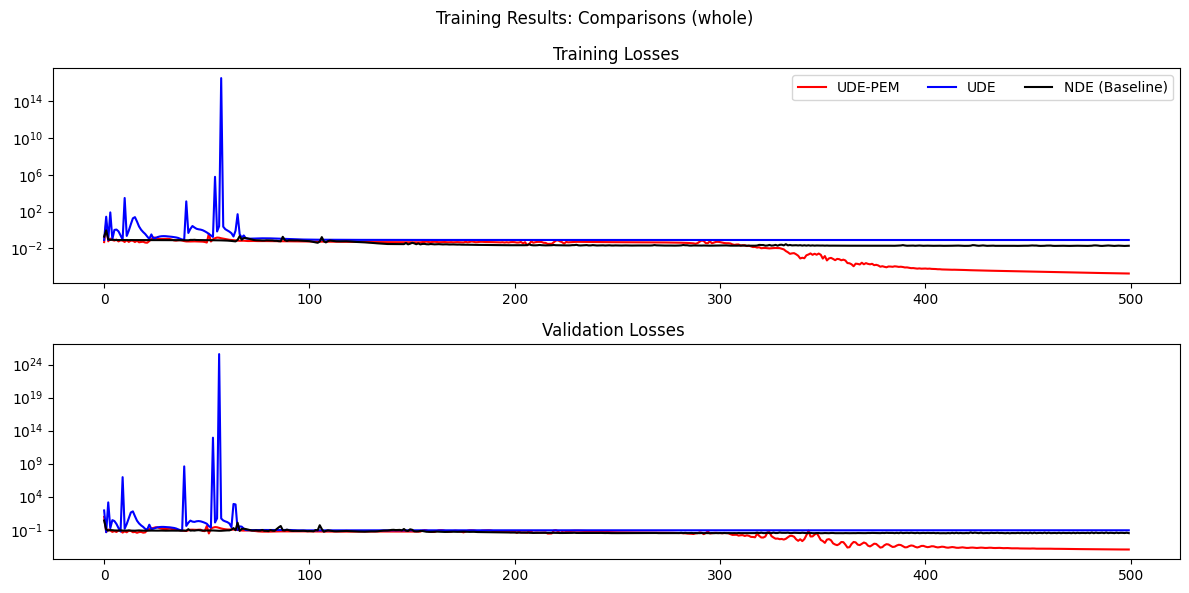

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

N = 365

plt.sca(axes[1])
plt.title("Validation Losses ")

plt.semilogy(range(0, 500), val_losses_pem, color='r')
plt.semilogy(val_losses, color='b')
plt.semilogy(baseline_val_losses, color='k')

plt.sca(axes[0])

plt.title("Training Losses")
plt.semilogy(train_losses_pem, color='r')
plt.semilogy(train_losses, color='b')
plt.semilogy(baseline_train_losses, color='k')


plt.plot([], [], color='r', label="UDE-PEM")
plt.plot([], [], color='b', label="UDE")
plt.plot([], [], color='k', label="NDE (Baseline)")

plt.legend(ncol=4)

plt.suptitle("Training Results: Comparisons (whole)")
plt.tight_layout()
plt.show()


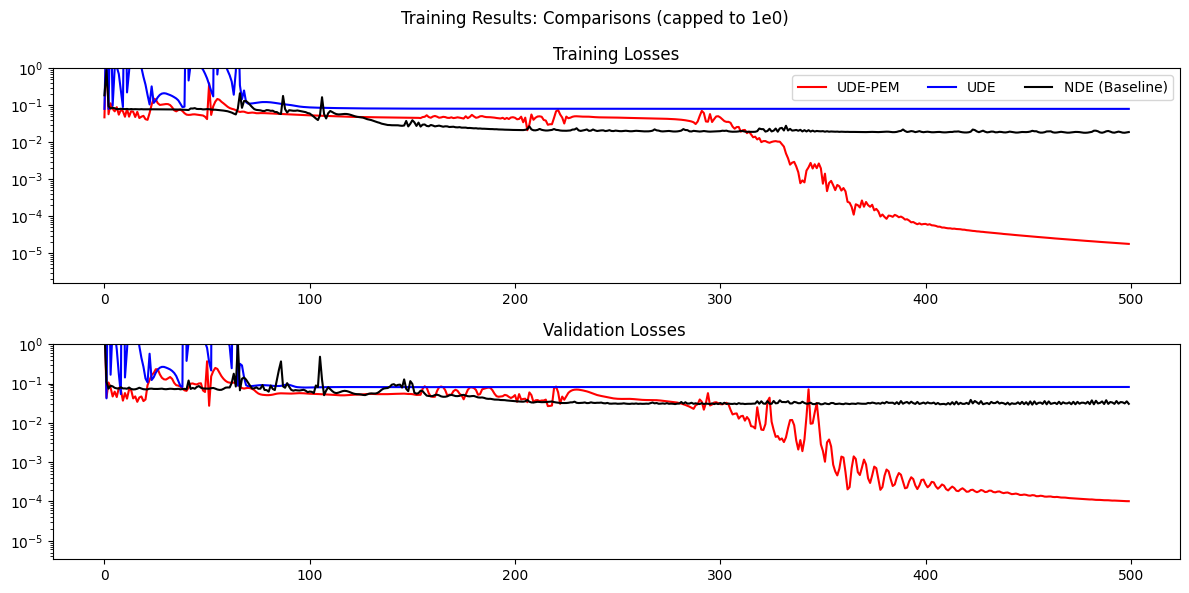

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

N = 365

plt.sca(axes[1])
plt.title("Validation Losses ")

plt.semilogy(range(0, 500), val_losses_pem, color='r')
plt.semilogy(val_losses, color='b')
plt.semilogy(baseline_val_losses, color='k')
plt.ylim(None, 1e0)

plt.sca(axes[0])

plt.title("Training Losses")
plt.semilogy(train_losses_pem, color='r')
plt.semilogy(train_losses, color='b')
plt.semilogy(baseline_train_losses, color='k')
plt.ylim(None, 1e0, )


plt.plot([], [], color='r', label="UDE-PEM")
plt.plot([], [], color='b', label="UDE")
plt.plot([], [], color='k', label="NDE (Baseline)")

plt.legend(ncol=4)

plt.suptitle("Training Results: Comparisons (capped to 1e0)")
plt.tight_layout()
plt.show()


In [43]:
# save model
eqx.tree_serialise_leaves("./models_weights/31_3_ude_jax.eqx", ude)
eqx.tree_serialise_leaves("./models_weights/31_3_ude_pem_jax.eqx", ude_pem)


In [11]:
# load model 
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.3, 0.1, 0.1], key)
ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_3_ude_pem_jax.eqx", ude_pem)

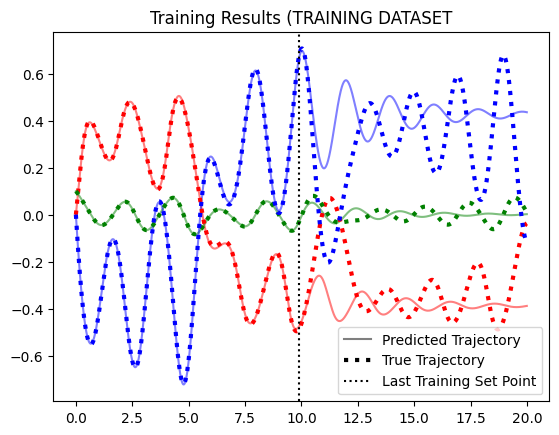

In [12]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 20

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(linear_interp_jit), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle=':',  linewidth=3)

plt.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="k", linestyle=':',  linewidth=3, label="True Trajectory")
plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results (TRAINING DATASET")
plt.show()

calcolo tempo di allontanamento rapportato su tempo caratt. w.r.t training points

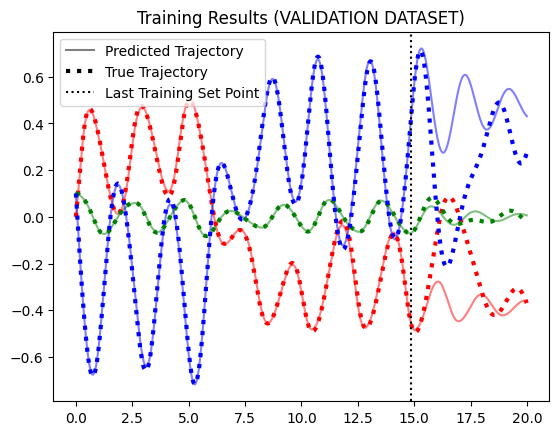

In [13]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 20

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(linear_interp_jit_val), saveat=saveat, stepsize_controller=stepper).ys

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle=':',  linewidth=3)

plt.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="k", linestyle=':',  linewidth=3, label="True Trajectory")
plt.axvline(t_val[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.legend()
plt.title("Training Results (VALIDATION DATASET)")
plt.show()

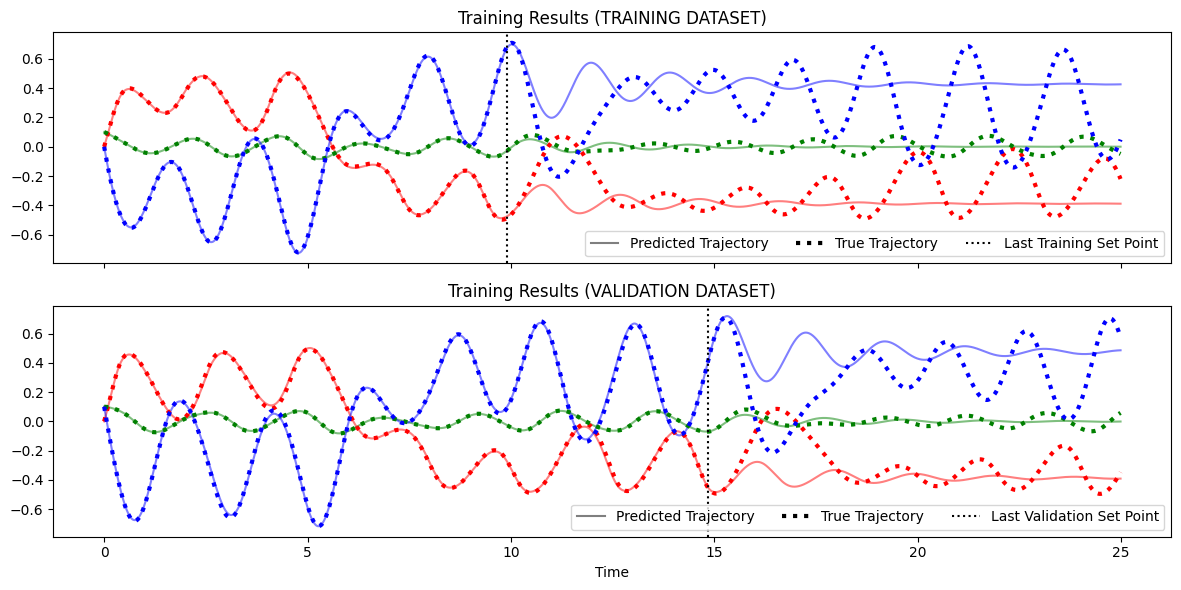

In [14]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 25

solver = dfx.Tsit5()
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# Create figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

datasets = [
    {
        "y0": x_train[0],
        "interp": linear_interp_jit,
        "title": "Training Results (TRAINING DATASET)"
    },
    {
        "y0": y0_alt,
        "interp": linear_interp_jit_val,
        "title": "Training Results (VALIDATION DATASET)"
    }
]

for ax, ds in zip(axes, datasets):

    # True trajectory
    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=T_MAX,
        dt0=0.1,
        y0=ds["y0"],
        args=(ALPHA, BETA, GAMMA, A, C),
        saveat=saveat,
        stepsize_controller=stepper
    )
    traj_true = sol.ys

    # Predicted trajectory
    traj_final = dfx.diffeqsolve(
        term_ude,
        solver,
        t0=0,
        t1=T_MAX,
        dt0=0.1,
        y0=ds["y0"],
        args=(ds["interp"]),
        saveat=saveat,
        stepsize_controller=stepper
    ).ys

    # Predicted
    ax.plot(t_eval, traj_final[:, 0], color='r', alpha=0.5)
    ax.plot(t_eval, traj_final[:, 1], color='g', alpha=0.5)
    ax.plot(t_eval, traj_final[:, 2], color='b', alpha=0.5)

    # Ground truth
    ax.plot(t_eval, traj_true[:, 0], color='r', linestyle=':', linewidth=3)
    ax.plot(t_eval, traj_true[:, 1], color='g', linestyle=':', linewidth=3)
    ax.plot(t_eval, traj_true[:, 2], color='b', linestyle=':', linewidth=3)

    # Legend helpers
    ax.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
    ax.plot([], [], color="k", linestyle=':', linewidth=3, label="True Trajectory")


    ax.set_title(ds["title"])

# Training boundaries
axes[0].axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")
axes[1].axvline(t_val[-1], color="k", linestyle=":", label="Last Validation Set Point")

axes[0].legend(ncol=3)
axes[1].legend(ncol=3)

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

# TODO: focus on the generalization part, and quantify in the following way:
1. Calculate characteristic time (inverse of lyapunov exponent)
2. Estimate the "divergence time" (by an epsilon whatever)
3. Divide it by characteristic time to obtain some sort of percentage

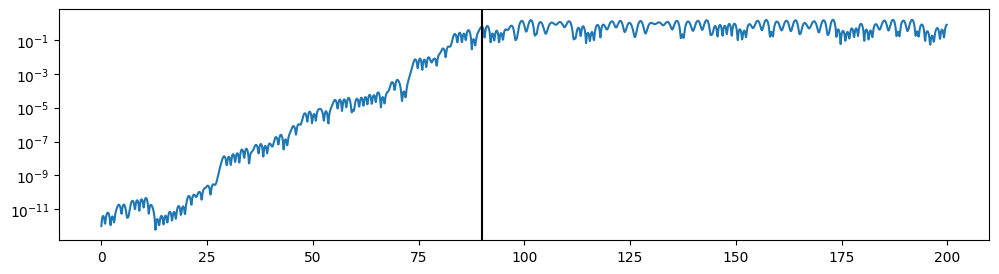

In [15]:
# Calculate the characteristic time
term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()


y0 = jnp.array((0.0001, 0.1, 0)) 

key = jax.random.PRNGKey(67)

v = jax.random.normal(key, shape=(3,))
v = v / jnp.linalg.norm(v)

delta = 1e-12

y0_alt = y0 + delta * v # randomly define a perturbation with norm \delta_0 = 10^-8
T_MAX = 200
saveat = dfx.SaveAt(ts=(ts:=jnp.arange(0, T_MAX, 0.1)))

# training set
traj_1 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat).ys
traj_2 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat).ys

fig, ax = plt.subplots(figsize=(12, 3))

plt.semilogy(ts, jnp.linalg.norm(traj_1-traj_2, axis=1))
plt.axvline(N:=90, color="k")

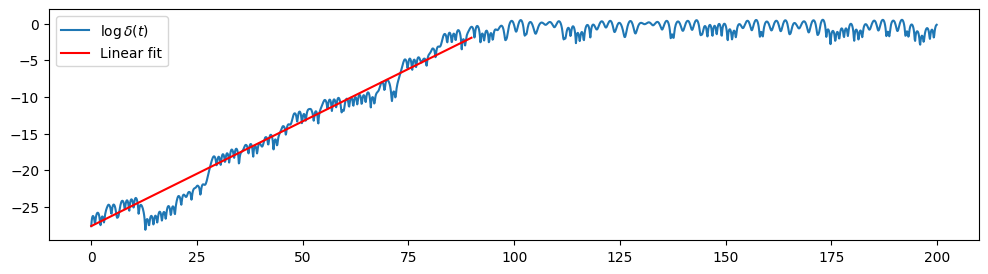

In [16]:
# Do linear regression over [0, 95] with fixed delta_0
from sklearn.linear_model import LinearRegression

fig, ax = plt.subplots(figsize=(12, 3))

log_diffs = jnp.log(jnp.linalg.norm(traj_1-traj_2, axis=1))

LinReg = LinearRegression(fit_intercept=False)

# zero the dataset at t=0
log_diffs_zerod = log_diffs[0: N*10] - log_diffs[0]
plt.plot(ts, log_diffs, color="C0", label=r"$\log \delta(t)$")

LinReg.fit(ts[:N*10].reshape(-1, 1), log_diffs_zerod)

predict = LinReg.predict(ts[:N*10].reshape(-1, 1))

plt.plot(ts[:N*10], predict+log_diffs[0], color="red", label="Linear fit")

plt.legend()

plt.show()

In [17]:
characteristic_time = 1/LinReg.coef_

In [18]:
LinReg.coef_

array([0.28587651])

In [19]:
characteristic_time

array([3.4980139])

In [39]:
# Function to estimate divergence time and divide by characteristic time
def get_ratio(initial_state: jax.typing.ArrayLike):
    T_MAX_TRAIN = 10

    term = dfx.ODETerm(chua_model)
    term_ude = dfx.ODETerm(ude_pem)
    solver = dfx.Tsit5()
    t_eval = jnp.arange(0, T_MAX_TRAIN, 0.01)
    saveat = dfx.SaveAt(ts=t_eval)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    # Step 1: get a "reasonable" training set for the linear interpolator of the PEM component
    
    traj: dfx.Solution = dfx.diffeqsolve(
        term, 
        solver, 
        t_eval[0], t_eval[-1], t_eval[1]-t_eval[0], 
        initial_state,
        args=(ALPHA, BETA, GAMMA, A, C),
        stepsize_controller=stepper, 
        saveat=saveat 
    ).ys # pyright: ignore[reportAssignmentType]
    
    linear_interp_current = LinearInterpolator(t_eval[::10], traj[::10])

    T_MAX = 20
    t_eval_extended = jnp.arange(0, T_MAX, 0.01)
    saveat_ext = dfx.SaveAt(ts=t_eval_extended)
    traj_true: dfx.Solution = dfx.diffeqsolve(
        term, 
        solver, 
        t_eval_extended[0], t_eval_extended[-1], t_eval_extended[1]-t_eval_extended[0], 
        initial_state,
        args=(ALPHA, BETA, GAMMA, A, C),
        stepsize_controller=stepper, 
        saveat=saveat_ext 
    ).ys # pyright: ignore[reportAssignmentType]


    traj_ude = dfx.diffeqsolve(
        term_ude,
        solver, 
        t_eval_extended[0], t_eval_extended[-1], t_eval_extended[1]-t_eval_extended[0], 
        initial_state,
        args=(linear_interp_current),
        stepsize_controller=stepper, 
        saveat=saveat_ext 
    ).ys

    log_diffs = jnp.log10(jnp.linalg.norm(traj_true-traj_ude, axis=1))

    t = jnp.where(log_diffs>-1)[0][0] * 0.01
    print(t)

    if False:
        fig, axes = plt.subplots(2, 1, figsize=(12,5))

        plt.sca(axes[0])
        plt.plot(t_eval_extended, (log_diffs))
        
        ax = axes[1]
        # Predicted
        ax.plot(t_eval_extended, traj_ude[:, 0], color='r', alpha=0.5)
        ax.plot(t_eval_extended, traj_ude[:, 1], color='g', alpha=0.5)
        ax.plot(t_eval_extended, traj_ude[:, 2], color='b', alpha=0.5)

        # Ground truth
        ax.plot(t_eval_extended, traj_true[:, 0], color='r', linestyle=':', linewidth=3)
        ax.plot(t_eval_extended, traj_true[:, 1], color='g', linestyle=':', linewidth=3)
        ax.plot(t_eval_extended, traj_true[:, 2], color='b', linestyle=':', linewidth=3)

        # Legend helpers
        ax.plot([], [], color="k", alpha=0.5, label="Predicted Trajectory")
        ax.plot([], [], color="k", linestyle=':', linewidth=3, label="True Trajectory")

        ax.axvline(t, linestyle=":", color="grey", label="Estimated Divergence Time")
        axes[0].axvline(t, linestyle=":", color="grey",  label="Estimated Divergence Time")

    if t > T_MAX_TRAIN: 
        return (t-T_MAX_TRAIN)/characteristic_time
    else:
        return 

In [40]:
for i in jnp.linspace(0, 0.1, 10):
    print(get_ratio(jnp.array([0.1, 0.1, i])))

10.47
[0.13436196]
10.48
[0.13722072]
10.43
[0.1229269]
9.68
None
11.36
[0.38879205]
7.76
None
10.700000000000001
[0.20011356]
5.8500000000000005
None
5.88
None
10.47
[0.13436196]


In [34]:

x_train[0]

Array([0.0001, 0.1   , 0.    ], dtype=float64)

In [35]:
get_ratio(x_train[0])


10.450000000000001


Array([0.12864443], dtype=float64)

In [36]:
get_ratio(x_val[0])


11.200000000000001


Array([0.34305181], dtype=float64)

In [37]:
get_ratio(jnp.array([0.1, 0.1, 0.01]))

10.48


Array([0.13722072], dtype=float64)

In [38]:
get_ratio(jnp.array([0.1, 0.1, 0.1]))

10.47


Array([0.13436196], dtype=float64)

In [57]:
get_ratio(jnp.array([-0.1, 0, -0.1]))

10.46


Array([0.13150319], dtype=float64)

Calculate the lyapunov exponents by variable

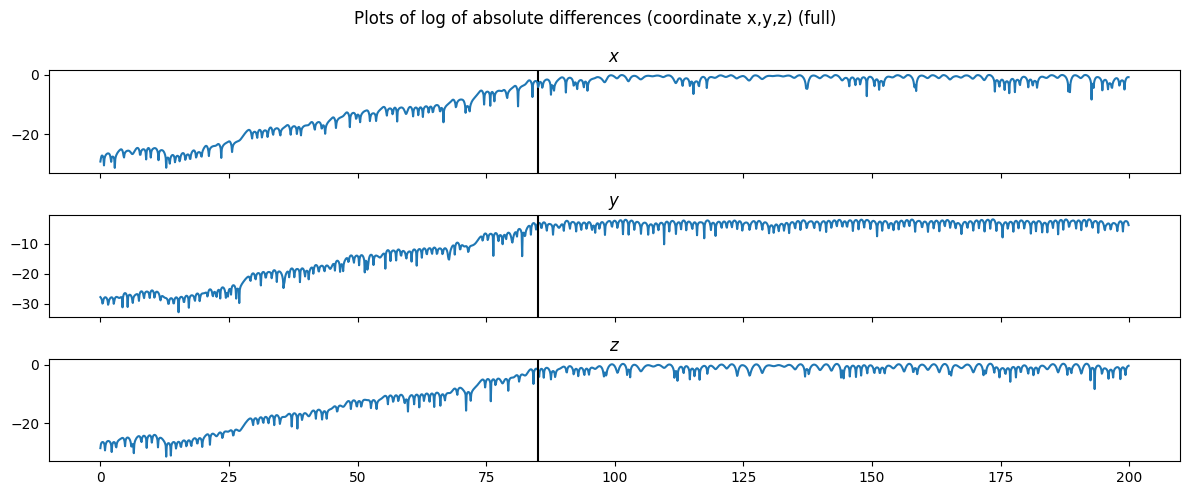

In [27]:
# Calculate the characteristic time
term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()


y0 = jnp.array((0.0001, 0.1, 0)) 

key = jax.random.PRNGKey(67)

v = jax.random.normal(key, shape=(3,))
v = v / jnp.linalg.norm(v)

delta = 1e-12

y0_alt = y0 + delta * v # randomly define a perturbation with norm \delta_0 = 10^-8
T_MAX = 200
saveat = dfx.SaveAt(ts=(ts:=jnp.arange(0, T_MAX, 0.1)))

# training set
traj_1 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat).ys
traj_2 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0_alt, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat).ys

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (full)")

plt.sca(axes[0])

t_eval = jnp.arange(0, 200, 0.1)
plt.axvline(N:=85, color="k")

plt.plot(t_eval[:], diff_x := jnp.log(jnp.abs(traj_1[:, 0] - traj_2[:, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[:], diff_y := jnp.log(jnp.abs(traj_1[:, 1] - traj_2[:, 1])))
plt.title("$y$")
plt.axvline(N:=85, color="k")

plt.sca(axes[2])
plt.plot(t_eval[:], diff_z := jnp.log(jnp.abs(traj_1[:, 2] - traj_2[:, 2])))
plt.title("$z$")
plt.axvline(N:=85, color="k")
plt.tight_layout()

plt.show()


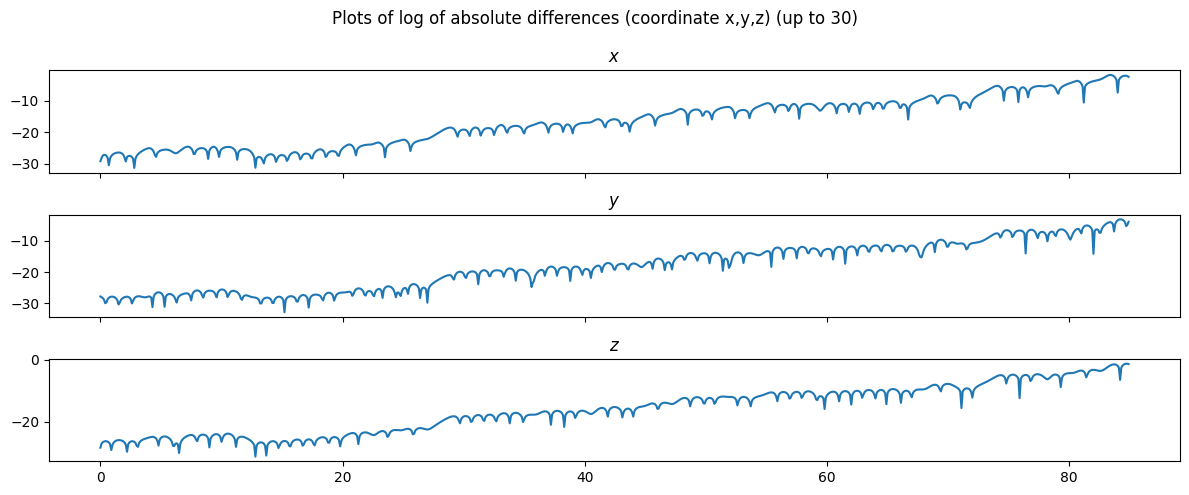

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (up to 30)")

MAX = 850

plt.sca(axes[0])
plt.plot(t_eval[0:MAX], diff_x := jnp.log(jnp.abs(traj_1[:MAX, 0] - traj_2[:MAX, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[:MAX], diff_y := jnp.log(jnp.abs(traj_1[:MAX, 1] - traj_2[:MAX, 1])))
plt.title("$y$")

plt.sca(axes[2])
plt.plot(t_eval[:MAX], diff_z := jnp.log(jnp.abs(traj_1[:MAX, 2] - traj_2[:MAX, 2])))
plt.title("$z$")

plt.tight_layout()

plt.show()


In [29]:
reg_x = LinearRegression(fit_intercept=False)
reg_y = LinearRegression(fit_intercept=False)
reg_z = LinearRegression(fit_intercept=False)

# manually modify intercept

reg_x.fit(t_eval[:MAX].reshape(-1, 1), diff_x-diff_x[0]) # Fit on the zero-centered datasets
reg_y.fit(t_eval[:MAX].reshape(-1, 1), diff_y-diff_x[1])
reg_z.fit(t_eval[:MAX].reshape(-1, 1), diff_z-diff_x[2])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
print(f"ESTIMATED LLE COEFFICIENTS:\n\tx: {reg_x.coef_}\n\ty: {reg_y.coef_}\n\tz: {reg_z.coef_}")

ESTIMATED LLE COEFFICIENTS:
	x: [0.29693234]
	y: [0.25086359]
	z: [0.27272007]


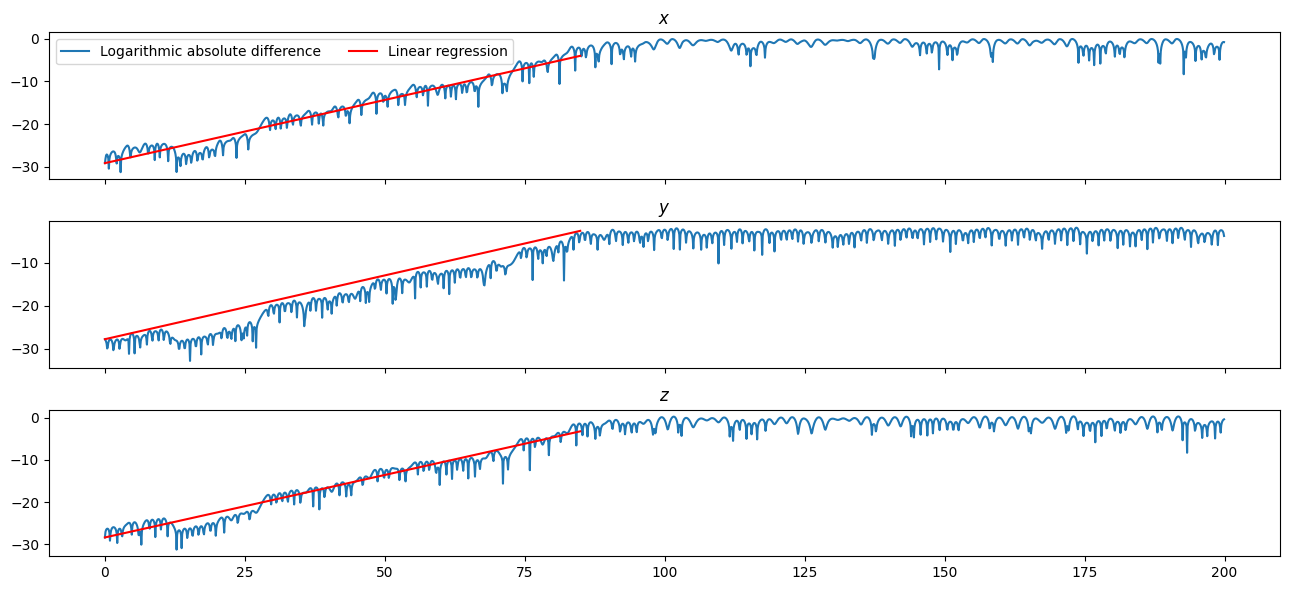

In [43]:
predict_x = reg_x.predict(t_eval[:MAX].reshape(-1, 1))+diff_x[0]
predict_y = reg_x.predict(t_eval[:MAX].reshape(-1, 1))+diff_y[0]
predict_z = reg_x.predict(t_eval[:MAX].reshape(-1, 1))+diff_z[0]


fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

predicts = {
    0: predict_x,
    1: predict_y,
    2: predict_z
}

diffs = {
    0: jnp.log(jnp.abs(traj_1[:, 0] - traj_2[:, 0])), 
    1: jnp.log(jnp.abs(traj_1[:, 1] - traj_2[:, 1])), 
    2: jnp.log(jnp.abs(traj_1[:, 2] - traj_2[:, 2]))
}

plt.sca(axes[0])
plt.plot([], [], color="C0", label="Logarithmic absolute difference")
plt.plot([], [], color='red', label ="Linear regression")
plt.legend(ncol=2)

for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval[:], diffs[i], color="C0")
    plt.plot(t_eval[:MAX], predicts[i], color='red')
    plt.title(f"${var_dict[i]}$")

plt.tight_layout()

plt.show()
